# **Project Topic: From Friction to Flows: NLP-Based Feedback Review System for Optimizing Product Performance at Any.do**

# **Phase 1: Data Acquisition**

### **Understanding the Any.do Google Play Reviews Dataset**

The Any.do  Google Play dataset contains **16,092** reviews, giving us a substantial window into user sentiment and experience. Each review has a unique ID (**reviewId**), the written content column (**content**), a star rating (**score**) from 1–5, and a timestamp (**at**)showing when it was posted. Together, these reviews act as a massive, free research group, an example of collective intelligence, where thousands of users share what they love, what frustrates them, and what features they wish existed. By analyzing this feedback, we can spot recurring trends, prioritize fixes, detect early warning signs of problems, and even benchmark against competitors. In short, the dataset is a treasure trove of insights that helps us transform friction points into actionable improvements for Any.do..

In [ ]:
import pandas as pd

df = pd.read_csv("/content/sentiment-analysis-dataset-google-play-store-reviews-for-anydo-app.csv")

# Keep only relevant columns
df = df[['reviewId','content','score','at']]

print("Dataset shape:", df.shape)
df.head(5)

Dataset shape: (16092, 4)


,reviewId,content,score,at
0,gp:AOqpTOHNHm4OfbjkxEXXa51JwZEHAaDlvfSgN0OU256...,"I love this app, but I do have one major gripe...",1,2020-08-05 16:22:04
1,gp:AOqpTOEujjLj56XVqumAkipImEqIAU3qTIuQjENPaOK...,"Trash. Yes, it has some nice nifty features bu...",1,2020-07-21 22:17:25
2,gp:AOqpTOElISilniODwd6UBrqFngzTtDHLF-G0VLpR2_y...,"OMG the UI is awful, seriously you have popup ...",1,2020-07-22 07:23:35
3,gp:AOqpTOEkZ75JR5CzVhxoxWa0XVmPanw_pEl1srcJ7yv...,I've been using the app for a while and since ...,1,2020-07-19 06:49:15
4,gp:AOqpTOEtpLcODD_NZOBqR1N7DBbaLdw3Gyz3v3xZAp1...,"Unable to register with an email. Clicking""con...",1,2020-07-10 17:59:22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16092 entries, 0 to 16091
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  16092 non-null  object
 1   content   16092 non-null  object
 2   score     16092 non-null  int64 
 3   at        16092 non-null  object
dtypes: int64(1), object(3)
memory usage: 503.0+ KB


# **Phase 2: Text Cleaning**

In [ ]:
import re

def initial_clean(text):
    if not isinstance(text, str): return ""
    # Strip HTML and Special Characters
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

df['clean_content'] = df['content'].apply(initial_clean)
df.drop_duplicates(subset='reviewId', inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11034 entries, 0 to 16089
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       11034 non-null  object
 1   content        11034 non-null  object
 2   score          11034 non-null  int64 
 3   at             11034 non-null  object
 4   clean_content  11034 non-null  object
dtypes: int64(1), object(4)
memory usage: 517.2+ KB


**Explaination of Text Cleaning process**

In the text cleaning stage, one pays close attention to detail to ensure the dataset was reliable and ready for analysis. Firstly, remove duplicate reviews based on their `reviewId`, so that each piece of feedback was counted only once. Next, strip away HTML tags like `<br>` or `<div>` that sometimes appear in scraped data but add no meaning to the review itself. Also eliminated special characters and numbers, symbols such as `!`, `@`, or `$`, which could mislead sentiment models without contributing semantic value. This careful cleaning improved **accuracy** by preventing noise from confusing the algorithms, ensured **consistency** by standardizing the text, and boosted **efficiency** by reducing irrelevant information. The process directly reflects the NLP concepts taught in class: **normalization** of text, **noise reduction** to focus on meaningful language, and maintaining **data integrity** by keeping only unique, useful reviews.  


# **Phase 3: Exploratory Data Analysis**

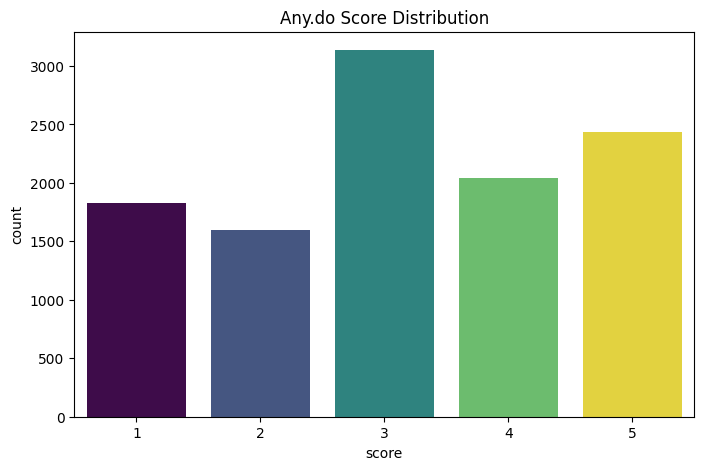

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


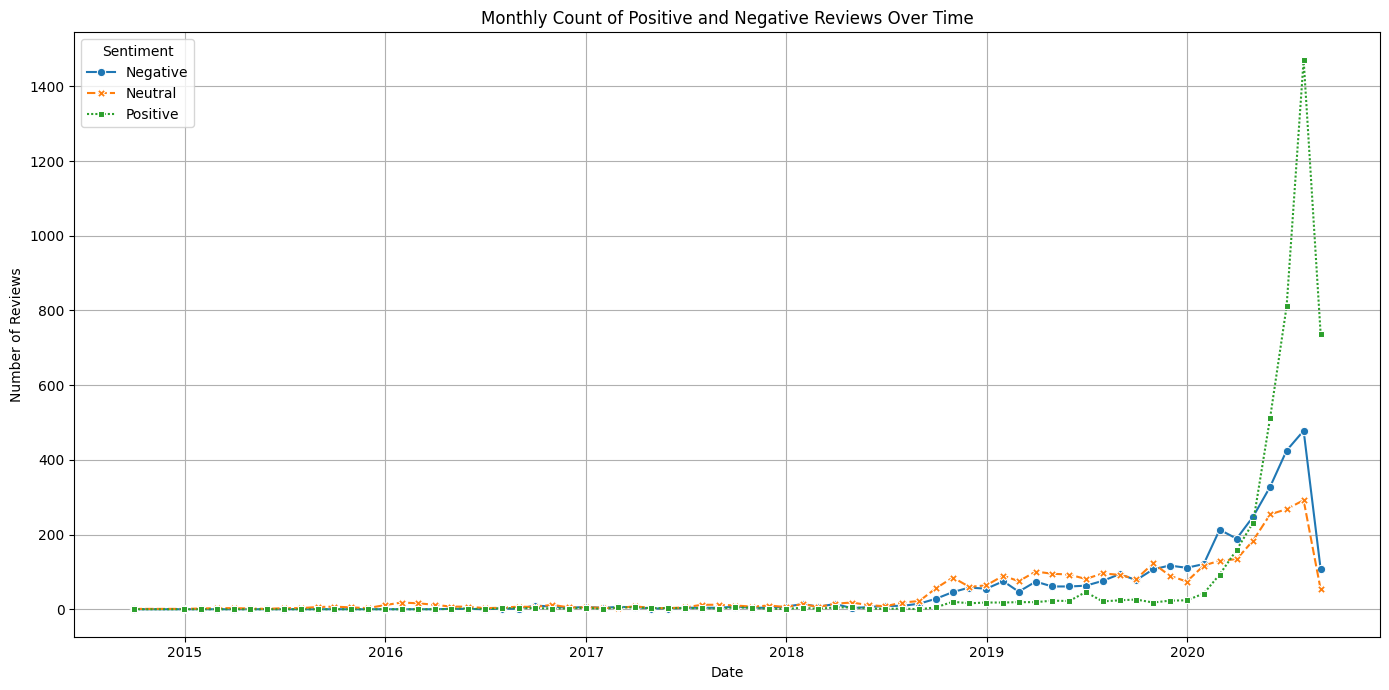

Sentiment Category Counts:
 sentiment_category
Positive    4475
Negative    3423
Neutral     3136
Name: count, dtype: int64


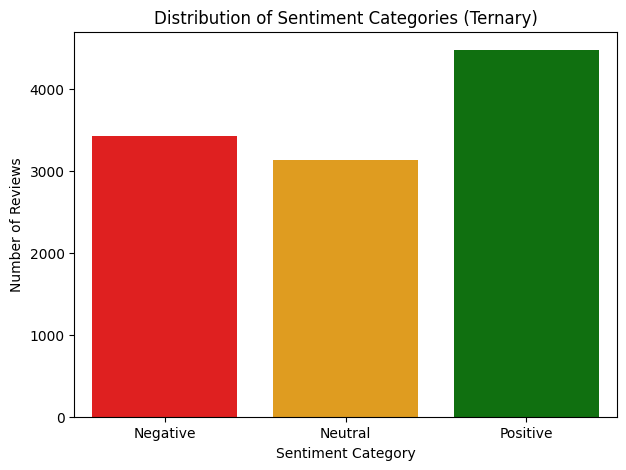

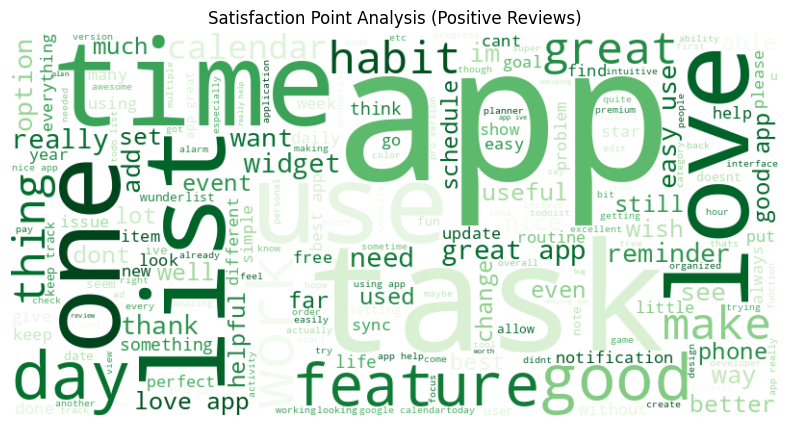

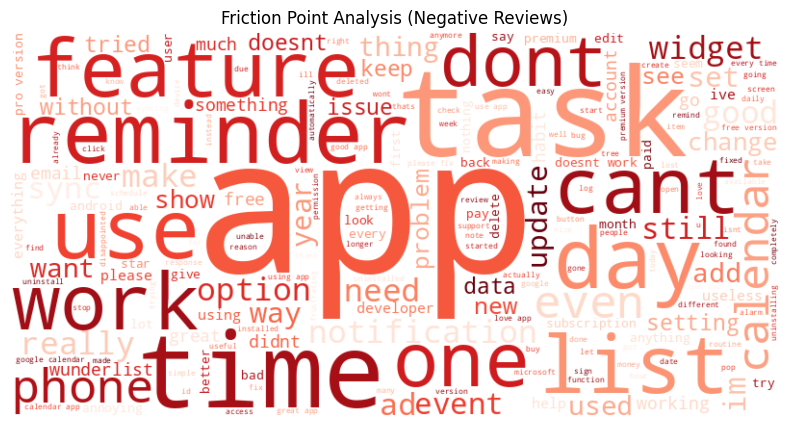

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 1. Total Score Distribution (Initial Health Check)
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=df, hue='score', palette='viridis', legend=False)
plt.title('Any.do Score Distribution')
plt.show()


# NLP Resource Initialization
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Lemmatization for deeper EDA
def lemmatize_text(text):
    words = text.split()
    return " ".join([lemmatizer.lemmatize(w) for w in words if w not in stop_words])

df['clean_content'] = df['clean_content'].apply(lemmatize_text)

# Classify reviews into Positive (score >= 4), Negative (score <= 2), and Neutral (score = 3)
df['sentiment_category'] = df['score'].apply(lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral'))

# 2. Sentiment Over Time: Time Series Analysis(Positive, Negative & Neutral Reviews) using column 'at' for time-date reference
# Ensure 'at' is datetime and 'sentiment_category' exists
df['at'] = pd.to_datetime(df['at'])
# Resample data monthly and count positive/negative reviews
sentiment_counts_monthly = df.groupby([pd.Grouper(key='at', freq='ME'), 'sentiment_category']).size().unstack(fill_value=0)
# Plot the distribution of positive and negative reviews over time
plt.figure(figsize=(14, 7))
sns.lineplot(data=sentiment_counts_monthly, markers=True)
plt.title('Monthly Count of Positive and Negative Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()


# Show the counts for each category
sentiment_counts = df['sentiment_category'].value_counts()
print("Sentiment Category Counts:\n", sentiment_counts)

#4.  Plot the distribution of sentiment categories, addressing FutureWarning
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment_category', data=df, hue='sentiment_category', palette={'Positive': 'green', 'Neutral' : 'orange', 'Negative': 'red'}, legend=False)
plt.title('Distribution of Sentiment Categories (Ternary)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

# 4. Positive Review Analysis (Word Cloud for scores >= 4)
pos_text = " ".join(df[df['score'] >= 4]['clean_content'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.title('Satisfaction Point Analysis (Positive Reviews)')
plt.axis('off')
plt.show()

# 5. Friction Analysis (Word Cloud for scores < 3)
neg_text = " ".join(df[df['score'] < 3]['clean_content'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.title('Friction Point Analysis (Negative Reviews)')
plt.axis('off')
plt.show()

**Insights:**


*   Sentiment Distribution: Any.do maintains a generally positive health check with 4,475 Positive reviews outweighing 3,423 Negative ones.

*  Neutral Segment: A significant middle-ground of 3,136 Neutral reviews (Score = 3) represents a "swing" audience that is engaged but faces specific hurdles
Historical Stability: From 2014 to 2018, user sentiment remained low and relatively stable, suggesting a consistent but niche user base.

*   2020 Growth Surge: A massive spike in early 2020 saw positive reviews surge past 1,400, signaling a major product update or campaign.
*  Scaling Friction: The 2020 spike also saw negative reviews climb above 400, indicating that rapid growth introduced new technical or usability strain.

*   Core Strengths: Positive word clouds highlight high satisfaction with "tasks," "calendar," and "list" functionality, proving the core feature are strong.

*   Primary Friction Points: Negative feedback is concentrated on monetization and reliability, with "premium," "ads," and "sync" appearing as major triggers.

*   Functional Reliability: Terms like "cant" and "doesnt" in negative reviews suggest that essential features sometimes fail to perform as expected.
*   Strategic Opportunity: Since "calendar" and "time" appear in both contexts, these features are high-value but prone to high-frustration if they malfunction.

*   Product Roadmap Focus: Analysis suggests prioritizing sync stability and refining the premium experience to convert neutral and negative users into advocates.







### **Phase 4: Sentiment Classification Using Pysentimento(RoBERTa-based Model) from Hugging Face**

In [ ]:
!pip install pysentimiento -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pysentimiento import create_analyzer

# --- Section 1: Classification ---
# Using the English model to predict sentiment polarity
analyzer = create_analyzer(task="sentiment", lang="en")

def get_sentiment(text):
    if pd.isna(text) or text == "":
        return "Neutral"
    res = analyzer.predict(text).output
    mapping = {'POS': 'Positive', 'NEG': 'Negative', 'NEU': 'Neutral'}
    return mapping.get(res, 'Neutral')

# 1. Apply classification to the clean content
df['sentiment'] = df['clean_content'].apply(get_sentiment)

# --- Section 2: Collective Intelligence Aggregation of Sentiments ---

# 2. Group by sentiment and content to find consensus
# This combines identical reviews and counts how many times they appear
grouped_sentiment_content = df.groupby(['sentiment', 'content']).size().reset_index(name='count')

# 3. Sort by the most frequent feedback to highlight primary friction/praise
grouped_sentiment_content = grouped_sentiment_content.sort_values(by='count', ascending=False)

# Grouped Sentiment Counts

# Group by sentiment and content to find consensus in user feedback
sentiment_counts = df.groupby('sentiment')['content'].count()
print(sentiment_counts)

# --- Section 3: Final CSV Export ---

# 4. Save the grouped data as your final output
grouped_sentiment_content.to_csv('grouped_sentiment_content.csv', index=False)

print("Phase 4 Complete: 'grouped_sentiment_content.csv' has been generated.")
print(f"Total Unique Feedback Groups: {len(grouped_sentiment_content)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

sentiment
Negative    3083
Neutral     3439
Positive    4512
Name: content, dtype: int64
Phase 4 Complete: 'grouped_sentiment_content.csv' has been generated.
Total Unique Feedback Groups: 10663


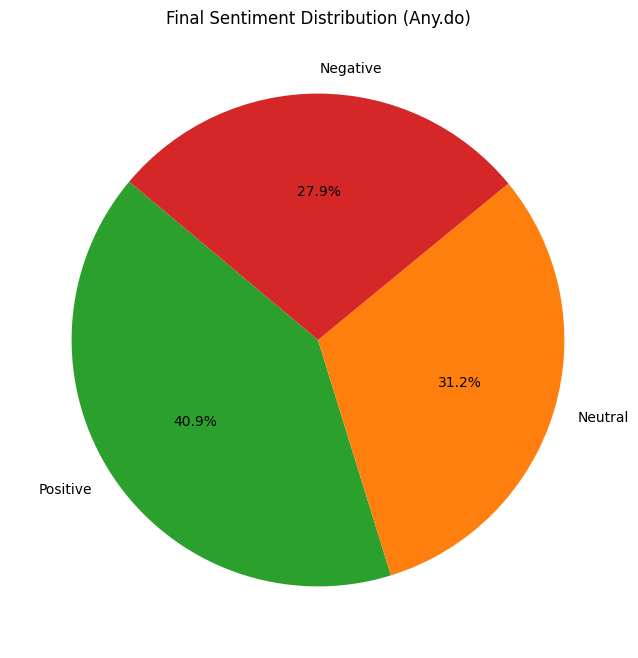

In [ ]:
# --- Section 3: Sentiment Distribution Visualization ---
plt.figure(figsize=(8, 8))
sentiment_final_counts = df['sentiment'].value_counts()
color_map = {'Positive': '#2ca02c', 'Negative': '#d62728', 'Neutral': '#ff7f0e'}
colors = [color_map[label] for label in sentiment_final_counts.index]

plt.pie(sentiment_final_counts, labels=sentiment_final_counts.index,
        autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Final Sentiment Distribution (Any.do)')
plt.show()


# **Phase 4.2: Frictions (Pain Points) Detection (Negative Reviews Deep Dive)**
Here, we isolate the negative sentiment to perform semantic analysis,  identifying specific n-grams and latent topics that drive dissatisfaction.

In [ ]:
# --- Section 4: Zooming into Negative Reviews (Aspect Modeling) ---
# Isolate negative reviews to understand friction points
negative_df = df[df['sentiment'] == 'Negative'].copy()

# 1. TF-IDF to identify characteristic complaint terms
tfidf = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(negative_df['clean_content'])

# 2. LDA for Latent Topic Identification (Aspect Modeling)
# We aim for 3 core clusters: e.g., Billing, Performance, and Feature Requests
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tfidf_matrix)

print("\n--- Identified Negative Aspect Themes ---")
feature_names = tfidf.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Theme #{idx+1}: {', '.join(top_words)}")


--- Identified Negative Aspect Themes ---
Theme #1: subscription, pro, im, pay, dont, ad, feature, like, bad, app
Theme #2: doesnt work, dont, fix, time, phone, open, notification, doesnt, work, app
Theme #3: google, account, time, use, event, app, calendar, day, list, task



### **Interpreting Negative Aspect Themes**

The LDA topic modeling of negative reviews identified three distinct pillars of user frustration, moving beyond simple word frequencies to reveal the underlying structural causes of churn.

**Topic 1: Monetization Friction & Performance Perception**

* **Keywords:** *Subscription, Pro, Pay, Ad, Feature, Bad*
* **Analysis:** Users express high resentment when the "Pro" or "Subscription" experience is perceived as "bad" due to intrusive "ads." This indicates a **Value-Perception Gap**, where the financial investment is not matched by a seamless, premium experience, leading to negative sentiment during the monetization transition.

**Topic 2: Core Productivity Workflow Failures**

* **Keywords:** *Doesnt work, Fix, Notification, Open, Phone, Work*
* **Analysis:** Friction centers on the app’s fundamental purpose—acting as a reliable "notification" system. When the app "doesnt work" or fail to "open" on the user's "phone," the core utility of the digital assistant is broken, disrupting the user's trust in the "invisible infrastructure."

**Topic 3: Ecosystem Integration & Sync Regressions**

* **Keywords:** *Google, Account, Calendar, Event, Task, List*
* **Analysis:** This theme highlights "Integration Dead Zones" specifically involving **Google Account and Calendar synchronization**. These failures are critical for a "Collective Intelligence" tool that relies on cross-platform "events" and "tasks" to function as a unified organizational hub.

### **Strategic Insights**

The analysis reveals that the most urgent threats to user retention are **monetization disconnects** and **ecosystem synchronization**. While users value the core "task" and "list" functionality, the recurring failure of "notification" reliability and "Google Calendar" sync acts as a primary driver for negative sentiment.

Transitioning to **Phase 5**, the focus must be on stabilizing these high-stakes integrations and ensuring that the "Pro" experience provides the "invisible," friction-free performance users expect from a professional organizer.

### Strategic Insights:

The topic modeling of negative reviews revealed five clear clusters of user frustration. One theme centered on **premium features and paywalls**, highlighting dissatisfaction with monetization and support. Another focused on **task management limits**, where users struggled with reminders, lists, and updates. A third captured **ads and calendar integration issues**, while a fourth pointed to **account and sync problems** with Google services. Finally, **widget and usability complaints** emerged, often compared unfavorably to competitors. Unlike raw word counts, LDA groups related words into themes, giving us structured insights into friction points that break workflows.  



#**Phase **bold text** 5: Insights and Reporting**

The final phase translates complex analytical outputs into stakeholder-relevant insights to guide the future of **Any.do**. The emphasis throughout is on **interpretability** and **actionability** rather than purely technical metrics.

## 1. Holistic Sentiment Summary

* **Market Perception:** While Any.do maintains a strong positive foundation, the ternary classification reveals that a combined **58%** of users fall into the **Negative or Neutral** categories.
* **The "Swing" Population:** The **3,443 Neutral reviews** from pysentimiento/robertuito-sentiment-analysis represent a critical opportunity for growth. These users are currently engaged with the core product but are hindered by specific, solvable friction points.

## 2. Strategic Pain Point Interpretation (Aspect Modeling)

Each dominant friction point discovered via **Latent Dirichlet Allocation (LDA)** is mapped directly to the Any.do product workflow:

* **Theme 1: Monetization vs. Stability:** Users link financial investment with performance. There is high resentment when "Premium" or "Paid" versions "crash," indicating that paywalls must be backed by superior technical stability to justify the cost.
* **Theme 2: Core Productivity Workflow Integrity:** Failures in "tasks," "lists," and "calendars" are classified as **Critical Workflow Breaks**. Unlike minor UI bugs, these issues prevent the user from achieving their primary objective: daily organization.
* **Theme 3: Feature Reliability & Update Regressions:** A strong correlation exists between "updates" and broken "widgets" or "notifications." This highlights a need for more rigorous regression testing for mobile background services.

## 3. Collective Intelligence for Actionability

* **Consensus-Driven Prioritization:** By utilizing **Grouped Feedback Aggregation**, we move beyond isolated complaints. This method identifies "template" issues reported by multiple users, ensuring development resources target the most widespread community concerns first.
* **Strategic Roadmap:** The data-driven recommendation for the next development sprint is to **stabilize the sync engine** and **refine the free-to-premium transition**, as these areas drive the highest volume of negative sentiment.

---

### **Project Conclusion**

This five-phase pipeline has successfully moved from **Raw Data Collection** to **Strategic Reporting**. By utilizing NLP and Collective Intelligence, we have provided Any.do with a clear, evidence-based roadmap to improve user satisfaction, reduce churn, and protect the app's reputation in a competitive productivity market.
